# Zadanie 2 – Kwantowy Efekt Halla

Pole magnetyczne $B_z = 2\,\mathrm{T}$ wprowadzamy przez fazę Peirerlsa.
Dla cechowania $\mathbf{A} = (-yB_z,\,0,\,0)$ całkując wzdłuż prostej $\mathbf{r}_n \to \mathbf{r}_m$:

$$t_{nm} \to t_{nm}\,\exp\!\left(-\frac{i}{2}B_z(x_m-x_n)(y_n+y_m)\right)$$

In [1]:
#importuje wszytskie potrzebne biblioteki w tym biblioteke kwant
import kwant
import numpy as np
import types
import matplotlib.pyplot as plt
      
    
#Obliczenia prowadze sa w jednostkach atomowych e=h=me=1. Tutaj definiuje wspolczynniki konwersji.
def eV2au(energy): #eV -> j.a
    return energy*0.03674932587122423
def nm2au(length): #nm -> j.a
    return length*18.89726133921252
def T2au(length):  #T -> j.a
    return length*4.254382E-6

/home/krzemon/Programming/Semestr_1/Symulacje nano-mezo/kwant_env/lib64/python3.13/site-packages/kwant/solvers/default.py:16: RuntimeWarning: MUMPS is not available, SciPy built-in solver will be used as a fallback. Performance can be very poor in this case.
  warnings.warn("MUMPS is not available, "


# Zdefiniowanie układu

In [2]:
############################################################################################
## W ramach zdefiniowania ukladu musimy zdefiniowac funkcje okreslajace energie potrzebne ##
## do przeskoku do tego samego wezla oraz wezlow sasiadujacych. Robimy to w funkcjach     ##
## onsite() oraz hopping_x() i hopping_y().
############################################################################################

#definicja ukladu do symulacji
def make_system(nw):
    m=nw.m
    dx=nw.dx
    L=nw.L
    W=nw.W
    B=nw.B
    V0=nw.V0
    s=nw.s
    x0=nw.x0
    y0=nw.y0

    #faza Peierlsa dla cechowania A=(-y*Bz, 0, 0)
    #calkujac po prostej r_n->r_m: phi = -Bz*(xm-xn)*(yn+ym)/2
    #element macierzowy: t_nm -> t_nm * exp(-i * phi)
    def peierls_phase(sitei, sitej):
        (xi, yi) = sitei.pos
        (xj, yj) = sitej.pos
        return np.exp(-1j * 0.5 * B * (xj - xi) * (yj + yi))

    #opcjonalny potencjal rozpraszajacy (uzywany w podzadaniu 6)
    def potential(site):
        (x, y) = site.pos
        return V0 * np.exp((-((x - x0*dx)**2) - (y - y0*dx)**2) / s**2)

    def onsite(site):
        (x, y) = site.pos
        t=1.0/(2.0*m*dx*dx)
        return 4*t + potential(site)

    def hopping_x(sitei, sitej):
        (xi, yi) = sitei.pos
        (xj, yj) = sitej.pos
        t=1.0/(2.0*m*dx*dx)        
        return -t * peierls_phase(sitei, sitej)
    
    def hopping_y(sitei, sitej):
         (xi, yi) = sitei.pos
         (xj, yj) = sitej.pos
         t=1.0/(2.0*m*dx*dx)
         return -t * peierls_phase(sitei, sitej)

    # W ramach definicji ukladu kolejno:
    # 1. Definujemy uklad - funkcja kwant.Builder()  
    # 2. Okreslamy geometrie siatki - kwant.lattice.square(dx, norbs=1)
    # 3. Uzupelniamy macierz
    sys = kwant.Builder()  
    lat = kwant.lattice.square(dx, norbs=1)
    sys[(lat(i,j) for i in range(L) for j in range(-W,W))]=onsite
    sys[(kwant.builder.HoppingKind((-1,0), lat, lat))] = hopping_x
    sys[(kwant.builder.HoppingKind((0,-1), lat, lat))] = hopping_y
    
    #dolaczam lewy kontakt do naszego ukladu
    lead_left = kwant.Builder(kwant.TranslationalSymmetry((-dx, 0)))    
    lead_left[(lat(0,j) for j in range(-W,W))]=onsite
    lead_left[(kwant.builder.HoppingKind((-1,0), lat, lat))] = hopping_x
    lead_left[(kwant.builder.HoppingKind((0,-1), lat, lat))] = hopping_y
    sys.attach_lead(lead_left)
    
    #prawy kontakt jako lustrzane odbicie lewego
    sys.attach_lead(lead_left.reversed())
    
    #finalizujemy uklad
    sys = sys.finalized()
    return sys

# Zdefiniowanie funkcji do liczenia transportu

In [3]:
############################################################################################
##       Definiujemy rozne funkcje liczace podstawowe wlasnosci fizyczne                  ##
############################################################################################

#funkcja wyliczajaca relacje dyspersji w kontakcie nr_lead w granicach [-k_max,k_max] z nk punktami
def disperssion(nw, nr_lead, k_max, nk):
    dx=nw.dx
    sys=make_system(nw)
    momenta = np.linspace(-k_max*dx,k_max*dx,nk)
    bands=kwant.physics.Bands(sys.leads[nr_lead])
    energies=[bands(k) for k in momenta]
    return (momenta/dx)*nm2au(1.0), energies

#funkcja liczaca wspolczynnik odbicia oraz wspolczynnik transmisji
def transmission_reflection(nw, E):
    E=eV2au(E)
    sys=make_system(nw)
    smatrix=kwant.smatrix(sys,E)
    r=smatrix.transmission(0,0)
    t=smatrix.transmission(1,0)
    return r, t

#funkcja liczaca wspolczynnik transmisji
def transmission(nw, E):
    E=eV2au(E)
    sys=make_system(nw)
    smatrix=kwant.smatrix(sys,E)
    t=smatrix.transmission(1,0)
    return t

#funkcja liczaca konduktacje - uzyto formuly Landauera
def conductance(nw, Emax, ne):
    energies=np.linspace(0,Emax,ne)
    cond=[transmission(nw, E) for E in energies]
    return energies, cond

#funkcja rysujaca funkcje falowa elektronu o energii E wchodzacego do kontaku nr_lead
def wave_function(nw, E, nr_lead):
    E=eV2au(E)
    sys=make_system(nw)
    wave=kwant.wave_function(sys, E)
    density=(abs(wave(nr_lead))**2).sum(axis=0)
    kwant.plotter.map(sys,density)

#funkcja rysujaca dos elektronu o energii E 
def dos(nw, E):
    E=eV2au(E)
    sys=make_system(nw)
    dos=kwant.ldos(sys, E)
    kwant.plotter.map(sys,dos)

#funkcja rysujaca prad elektronu o energii E wchodzacego do kontaku nr_lead w stanie nr_mod
def current(nw, E, nr_lead, nr_mod):
    E=eV2au(E)
    sys=make_system(nw)
    current = kwant.operator.Current(sys).bind()
    psi=kwant.wave_function(sys, E)(nr_lead)
    curr=current(psi[nr_mod])
    kwant.plotter.current(sys,curr)

# Definicja parametrów układu (W = 80 nm)

In [4]:
lenght=200
width=40   # calkowita szerokosc 2*W = 80 nm

nw = types.SimpleNamespace(\
                     dx=nm2au(1),
                     L=lenght,
                     W=width,
                     m=0.014,
                     B=T2au(2),
                     V0=eV2au(0),
                     s=nm2au(10),
                     x0=lenght/2,
                     y0=width,
                       )

# Nasz układ

/home/krzemon/Programming/Semestr_1/Symulacje nano-mezo/kwant_env/lib64/python3.13/site-packages/kwant/_plotter.py:77: RuntimeWarning: plotly is not available, if other engines are unavailable, only iterator-providing functions will work
  warnings.warn("plotly is not available, if other engines are unavailable,"


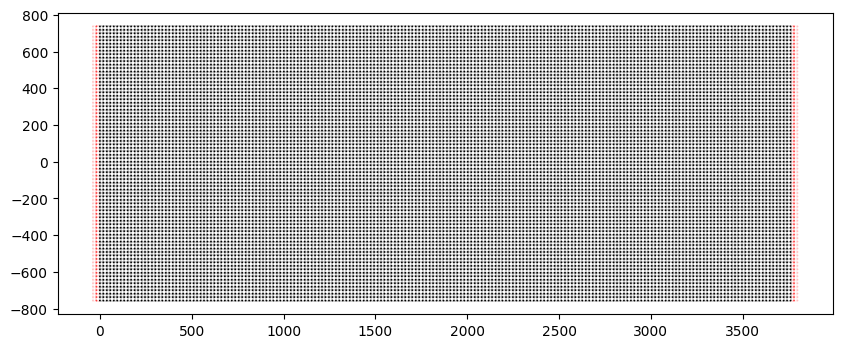

In [5]:
sys=make_system(nw)
kwant.plot(sys, site_color=lambda site: sys.hamiltonian(site,site), fig_size=(10,5), colorbar=False, show=False, num_lead_cells=2);

# Relacje dyspersji – W = 80 nm

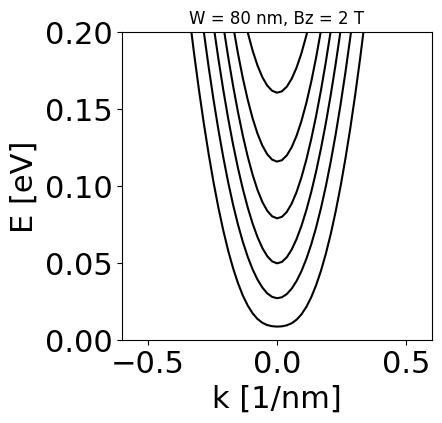

In [ ]:
#relacja dyspersji dla W=80 nm – widoczne plaskie poziomy Landaua
#oraz skosne galazki stanow brzegowych propagujacych w jednym kierunku
momenta, energies = disperssion(nw, 0, .1, 201)
plt.figure(figsize=(4,4))
plt.plot(momenta, np.asarray(energies)/eV2au(1.0),'k-')
plt.tick_params(axis='both', which='major', labelsize=22)
plt.ylim((0,.2))  
plt.xlim((-0.6,.6))  
plt.xlabel("k [1/nm]",fontsize=22)
plt.ylabel("E [eV]",fontsize=22)
plt.title("W = 80 nm, Bz = 2 T")
plt.show()

# Relacje dyspersji – W = 200 nm

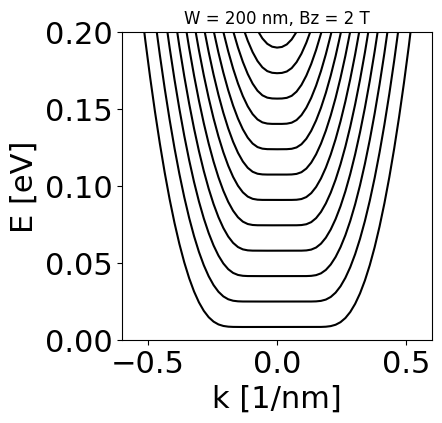

Energia robocza: 0.0207 eV


In [ ]:
#relacja dyspersji dla W=200 nm - szerszy uklad, stany brzegowe wyrazniej oddzielone
nw.W  = 100   # 2*W = 200 nm
nw.y0 = 100

momenta, energies = disperssion(nw, 0, .1, 201)
ene = np.asarray(energies)/eV2au(1.0)
plt.figure(figsize=(4,4))
plt.plot(momenta, ene,'k-')
plt.tick_params(axis='both', which='major', labelsize=22)
plt.ylim((0,.2))  
plt.xlim((-0.6,.6))  
plt.xlabel("k [1/nm]",fontsize=22)
plt.ylabel("E [eV]",fontsize=22)
plt.title("W = 200 nm, Bz = 2 T")
plt.show()

#energia robocza: nieco powyzej wypaszczenia pierwszego poziomu Landaua
lowest_E = float(np.min(ene)) * 2.5
print(f"Energia robocza: {lowest_E:.4f} eV")

# Obliczenia konduktancji (W = 200 nm, $B_z = 2\,\mathrm{T}$)

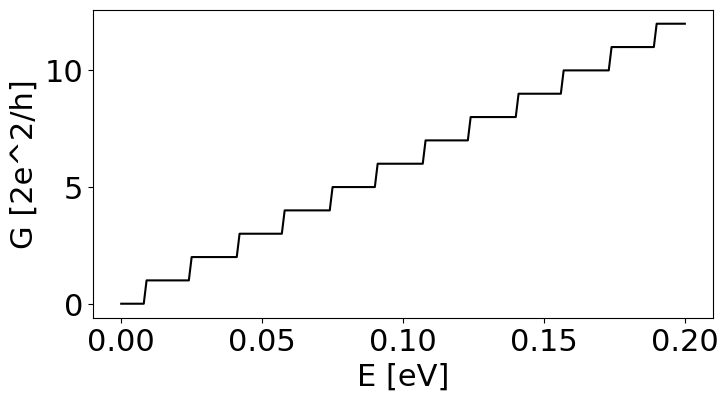

In [8]:
#konduktancja G(E) – spodziewamy sie skwantowanych plateau G = 1, 2, 3 ... [e^2/h]
energies, cond=conductance(nw,0.2,201)
plt.figure(figsize=(8,4))
plt.plot(energies, cond,'k-')
plt.tick_params(axis='both', which='major', labelsize=22)
plt.xlabel("E [eV]",fontsize=22)
plt.ylabel("G [2e^2/h]",fontsize=22)
plt.show()

# Funkcje falowe najniższego stanu

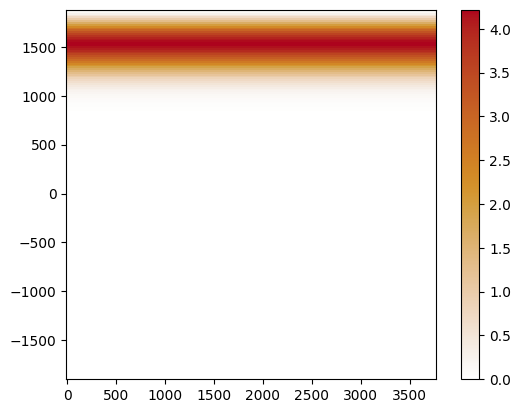

In [9]:
#funkcja falowa najnizszego stanu z lewego kontaktu – elektron plynie dolnym brzegiem
wave_function(nw, lowest_E, 0)

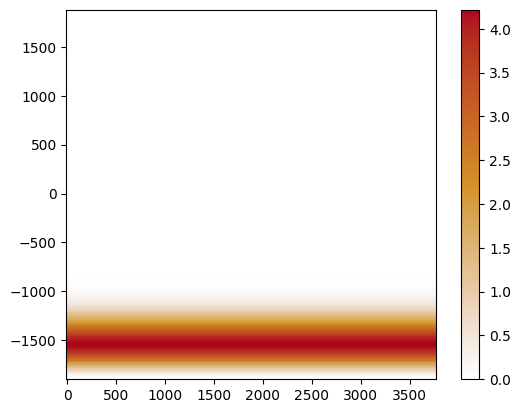

In [10]:
#funkcja falowa najnizszego stanu z prawego kontaktu – elektron plynie gornym brzegiem
wave_function(nw, lowest_E, 1)

# Potencjał rozpraszający na górnym brzegu

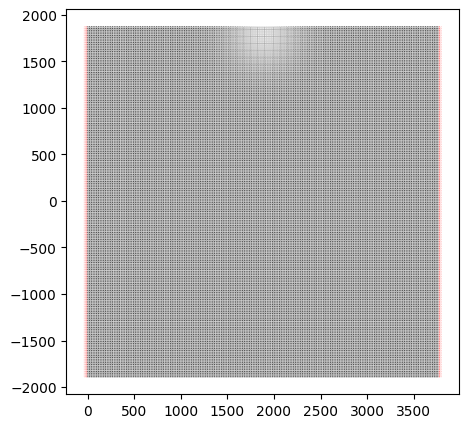

In [11]:
#ustawiamy potencjal rozpraszajacy na gornym brzegu probki
nw.V0 = eV2au(0.05)
nw.s  = nm2au(20)
nw.x0 = nw.L / 2
nw.y0 = nw.W - 5   # blisko gornego brzegu

sys=make_system(nw)
kwant.plot(sys, site_color=lambda site: sys.hamiltonian(site,site), fig_size=(10,5), colorbar=False, show=False, num_lead_cells=2);

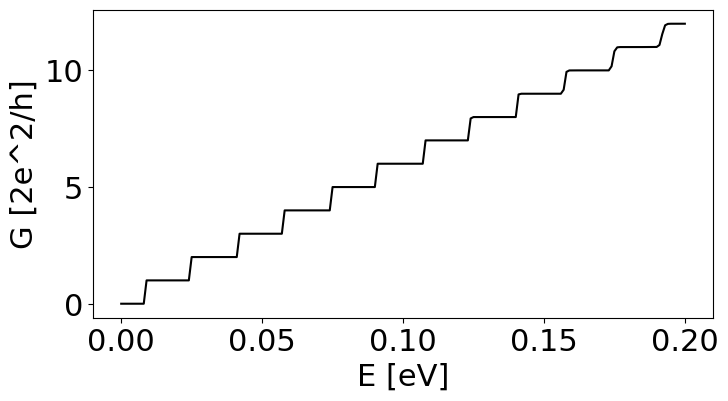

In [ ]:
#konduktancja z potencjalem na gornym brzegu
energies, cond=conductance(nw,0.2,201)
plt.figure(figsize=(8,4))
plt.plot(energies, cond,'k-')
plt.tick_params(axis='both', which='major', labelsize=22)
plt.xlabel("E [eV]",fontsize=22)
plt.ylabel("G [2e^2/h]",fontsize=22)
plt.show()

/tmp/ipykernel_5163/2420083870.py:43: RuntimeWarning: The plotted data contains 1.24% of values overflowing upper limit 4.74259 
  kwant.plotter.map(sys,density)


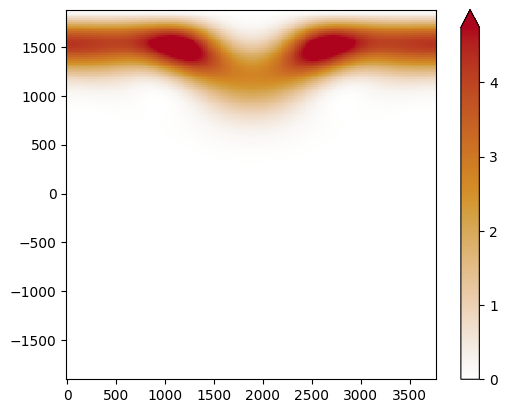

In [ ]:
#funkcja falowa z lewego kontaktu – prad oplewa potencjal i nie ulega odbiciu
wave_function(nw, lowest_E, 0)

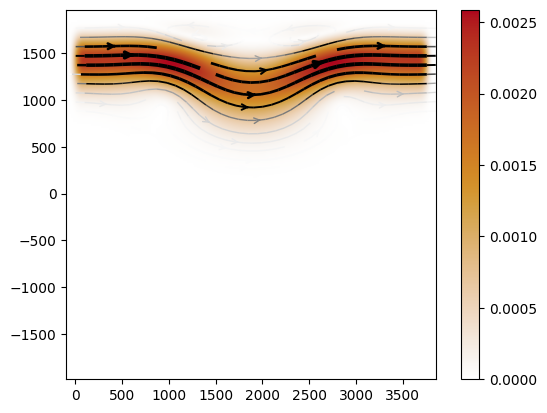

In [14]:
current(nw, lowest_E, 0, 0)